# Script to estimate airborne fraction trends with all LULC measurement

combinations

Fossil emissions and atmospheric growth from GCB 2025 with LULC panel measurements

[J. Eduardo Vera-Valdés](https://everval.github.io) [](https://orcid.org/0000-0002-0337-8055) (Aalborg University, CoRE)

This script estimates airborne-fraction trends using the GCB 2025 fossil-emissions and atmospheric-growth series together with all LULC measurement combinations produced by the LULC extraction script. The LULC panel includes the extracted bookkeeping series and all peat-augmented model combinations. We use the cross-measurement dispersion of that full LULC panel to construct delta-method weights, then replicate the OLS and WLS trend analysis for the full sample and for the sample ending in 2023.

## Script to run the analysis

Load the dataset and the LULC measurement panel.

In [1]:
#| warning: false
#| message: false
#| output: false
cd(@__DIR__)
using Pkg
Pkg.activate(pwd())

using CSV
using DataFrames
using Statistics
include(joinpath(@__DIR__, "estimation_functions.jl"))

dataframe_to_markdown_table (generic function with 1 method)

In [1]:
data_path = joinpath(@__DIR__, "..", "data", "Data_GCB_2025_cols.csv")
lulc_path = joinpath(@__DIR__, "..", "results", "LULC_measurements_extracted_and_derived.csv")

df = CSV.read(data_path, DataFrame)
lulc_df = CSV.read(lulc_path, DataFrame)
rename!(lulc_df, :year => :Year)

last(df[:, 1:5], 5)

## Build the airborne-fraction series

The numerator is the atmospheric-growth series from the GCB 2025 data. The denominator uses the fossil-emissions series together with the average of all LULC measurement combinations extracted from the results folder.

In [1]:
lulc_measure_cols = filter(col -> col != "Year", names(lulc_df))

analysis_df = innerjoin(
    select(df, :Year, :"fossil emissions excluding carbonation", :"atmospheric growth"),
    lulc_df,
    on = :Year,
)

rename!(analysis_df,
    "fossil emissions excluding carbonation" => "Fossil",
    "atmospheric growth" => "Growth",
)

analysis_df.LULC = vec(sum(Matrix(analysis_df[:, lulc_measure_cols]), dims = 2) ./ length(lulc_measure_cols))
analysis_df.lulc_var = vec(var(Matrix(analysis_df[:, lulc_measure_cols]), dims = 2))
analysis_df.AF = analysis_df.Growth ./ (analysis_df.Fossil .+ analysis_df.LULC)
analysis_df.AF_var = (analysis_df.Growth ./ (analysis_df.Fossil .+ analysis_df.LULC).^2).^2 .* analysis_df.lulc_var

first(analysis_df[:, [:Year, :Fossil, :Growth, :LULC, :AF]], 5)

## Build the benchmark AF series with GCB LULC only

In [1]:
gcb_df = select(
    df,
    :Year,
    :"fossil emissions excluding carbonation",
    :"land-use change emissions",
    :"atmospheric growth",
)

rename!(
    gcb_df,
    "fossil emissions excluding carbonation" => "Fossil",
    "land-use change emissions" => "LULC",
    "atmospheric growth" => "Growth",
)

gcb_df.AF = gcb_df.Growth ./ (gcb_df.Fossil .+ gcb_df.LULC)

66-element Vector{Float64}:
 0.4257518885330258
 0.3250744147703767
 0.35612609248079796
 0.25809551213965554
 0.25760182231888434
 0.21809997679591522
 0.4837565947172064
 0.48147820942203995
 0.2567747233407138
 0.40060061950520787
 ⋮
 0.5421184254718512
 0.4034215042099619
 0.4469379858938238
 0.46352405204661856
 0.4570371341047932
 0.44418050230595607
 0.42118215829888267
 0.49048798782563247
 0.6721946854759681

## Full-sample estimation

In [1]:
T = nrow(analysis_df)
T_gcb = nrow(gcb_df)
t = analysis_df.Year .- minimum(analysis_df.Year)
model_ols_gcb = robust_est(gcb_df.AF, hcat(ones(T_gcb), t), verbose = true)
model_wls_gcbaf_allw = robust_est(gcb_df.AF, hcat(ones(T_gcb), t), w = 1 ./ analysis_df.AF_var, verbose = true)
model_ols = robust_est(analysis_df.AF, hcat(ones(T), t), verbose = true)
model_wls = robust_est(analysis_df.AF, hcat(ones(T), t), w = 1 ./ analysis_df.AF_var, verbose = true)

Estimated coefficients: [0.37140953856437986, 0.0015814220456757773]
Standard errors: [0.02903879310089327, 0.0007708357734376027]
HAC Standard errors: [0.02729321112631395, 0.0006228416936395207]
t-statistics: [12.79011621708737, 2.051568051419437]
HAC t-statistics: [13.60812902686618, 2.5390433264588896]
p-values: [0.0, 0.04021165975931962]
HAC p-values: [0.0, 0.011115605670863893]
Residual sum of squares: 0.9108661139623042
σ²: 0.11929913256457904
Estimated coefficients: [0.2757267142199613, 0.0026492184376900978]
Standard errors: [0.0009226828438820532, 2.2192971989482706e-5]
HAC Standard errors: [0.03775408075608228, 0.0006471406684052407]
t-statistics: [298.83151729567385, 119.37195428109257]
HAC t-statistics: [7.303229444291025, 4.093728870754808]
p-values: [0.0, 0.0]
HAC p-values: [2.808864252301646e-13, 4.244906590611386e-5]
Residual sum of squares: 1.1835969859033475
σ²: 0.10793324154854425
Estimated coefficients: [0.4019380374160654, 0.0011722969671288848]
Standard errors: [

(β = [0.30194321805325625, 0.0023047206145638617], σ² = 0.11114715038672413, stderr = [0.000950157405974731, 2.285380814893778e-5], stderr_hac = [0.03896092180475498, 0.0006623745766980423], t_stat = [317.78231286162946, 100.84623969642375], t_stat_hac = [7.749899234068061, 3.479482298449565], pvalues = [0.0, 0.0], pvalues_hac = [9.103828801926284e-15, 0.000502383557222208], u = [0.1572096019437687, 0.02814381267742927, 0.08942627672636971, -0.02273091994300236, -0.029867655290505335, -0.0713467343865373, 0.20299164985818635, 0.20306514237479778, -0.035384924132036144, 0.11174174200881992  …  0.12006069743932468, 0.11804114247828179, -0.02175752020716054, 0.012688933744721909, 0.0256883810541077, 0.02272826284831786, 0.007360593627077361, -0.020811401401964635, 0.041839457746227215, 0.230306433085326], Yfit = [0.30194321805325625, 0.30424793866782013, 0.30655265928238395, 0.30885737989694784, 0.3111621005115117, 0.31346682112607555, 0.3157715417406394, 0.31807626235520325, 0.3203809829

In [1]:
gcb_df.AF_ols_trend = model_ols_gcb.Yfit
gcb_df.AF_wls_allw_trend = model_wls_gcbaf_allw.Yfit
analysis_df.AF_ols_trend = model_ols.Yfit
analysis_df.AF_wls_trend = model_wls.Yfit

66-element Vector{Float64}:
 0.30194321805325625
 0.30424793866782013
 0.30655265928238395
 0.30885737989694784
 0.3111621005115117
 0.31346682112607555
 0.3157715417406394
 0.31807626235520325
 0.32038098296976714
 0.322685703584331
 ⋮
 0.43331229308339636
 0.43561701369796024
 0.43792173431252407
 0.44022645492708795
 0.44253117554165183
 0.44483589615621566
 0.44714061677077954
 0.4494453373853434
 0.45175005799990725


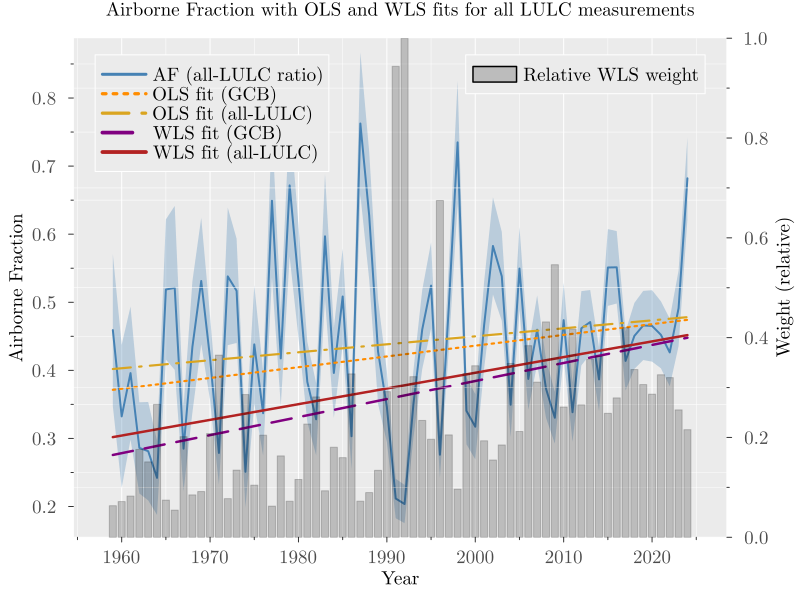

In [1]:
using Plots.PlotMeasures

w_rel = (1 ./ analysis_df.AF_var) ./ maximum(1 ./ analysis_df.AF_var)
af_sd = sqrt.(analysis_df.AF_var)

p = plot(
    analysis_df.Year,
    analysis_df.AF;
    color = :steelblue,
    linewidth = 2.0,
    label = "AF (all-LULC ratio)",
    ribbon = 1.96 .* af_sd,
    fillalpha = 0.3,
    title = "Airborne Fraction with OLS and WLS fits for all LULC measurements",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (800, 600),
    margin = 3mm,
)
plot!(
    p,
    gcb_df.Year,
    gcb_df.AF_ols_trend;
    color = :darkorange,
    linewidth = 2.2,
    linestyle = :dot,
    label = "OLS fit (GCB)",
)
plot!(
    p,
    analysis_df.Year,
    analysis_df.AF_ols_trend;
    color = :goldenrod,
    linewidth = 2.2,
    linestyle = :dashdot,
    label = "OLS fit (all-LULC)",
)
plot!(
    p,
    gcb_df.Year,
    gcb_df.AF_wls_allw_trend;
    color = :purple,
    linewidth = 2.5,
    linestyle = :dash,
    label = "WLS fit (GCB)",
)
plot!(
    p,
    analysis_df.Year,
    analysis_df.AF_wls_trend;
    color = :firebrick,
    linewidth = 2.5,
    linestyle = :solid,
    label = "WLS fit (all-LULC)",
    ylabel = "Airborne Fraction",
    legend = :topleft
)
p2 = twinx()
bar!(
    p2,
    analysis_df.Year,
    w_rel;
    bar_width = 0.8,
    color = :black,
    alpha = 0.2,
    label = "Relative WLS weight",
    ylabel = "Weight (relative)",
    legend = :topright,
    grid=false
)
p

In [1]:
savefig(p, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_robustness.png"))
savefig(p, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_robustness.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_trends_WLS_robustness.pdf"

## Sample ending in 2023

In [1]:
analysis_2023 = analysis_df[analysis_df.Year .< 2024, :]
gcb_2023 = gcb_df[gcb_df.Year .< 2024, :]
t_2023 = analysis_2023.Year .- minimum(analysis_2023.Year)

T_2023 = nrow(analysis_2023)
T_gcb_2023 = nrow(gcb_2023)
model_ols_gcb_2023 = robust_est(gcb_2023.AF, hcat(ones(T_gcb_2023), t_2023), verbose = true)
model_wls_gcbaf_allw_2023 = robust_est(gcb_2023.AF, hcat(ones(T_gcb_2023), t_2023), w = 1 ./ analysis_2023.AF_var, verbose = true)
model_ols_2023 = robust_est(analysis_2023.AF, hcat(ones(T_2023), t_2023), verbose = true)
model_wls_2023 = robust_est(analysis_2023.AF, hcat(ones(T_2023), t_2023), w = 1 ./ analysis_2023.AF_var, verbose = true)

gcb_2023.AF_ols_trend = model_ols_gcb_2023.Yfit
gcb_2023.AF_wls_allw_trend = model_wls_gcbaf_allw_2023.Yfit
analysis_2023.AF_ols_trend = model_ols_2023.Yfit
analysis_2023.AF_wls_trend = model_wls_2023.Yfit

Estimated coefficients: [0.37750162207030774, 0.0012958556313354018]
Standard errors: [0.028805128196206606, 0.0007765342139693791]
HAC Standard errors: [0.026875361957388016, 0.0005779627017676712]
t-statistics: [13.105361639043895, 1.6687682371539407]
HAC t-statistics: [14.046382804773085, 2.242109443000542]
p-values: [0.0, 0.09516331981129511]
HAC p-values: [0.0, 0.024954299849514916]
Residual sum of squares: 0.869196082824729
σ²: 0.11745962378383534
Estimated coefficients: [0.2833951906617748, 0.002367178254374574]
Standard errors: [0.0009077626486156625, 2.2042829825945897e-5]
HAC Standard errors: [0.03635275932232302, 0.0005850490213792302]
t-statistics: [312.19084756786623, 107.38994371712863]
HAC t-statistics: [7.79569958222542, 4.046119500882241]
p-values: [0.0, 0.0]
HAC p-values: [6.439293542825908e-15, 5.207365725512503e-5]
Residual sum of squares: 1.1280862439636181
σ²: 0.1054229422848318
Estimated coefficients: [0.4082124728254742, 0.0008781828073128439]
Standard errors: [

65-element Vector{Float64}:
 0.30981814167465355
 0.31183322915040196
 0.3138483166261504
 0.31586340410189884
 0.31787849157764725
 0.3198935790533957
 0.3219086665291441
 0.32392375400489254
 0.325938841480641
 0.3279539289563894
 ⋮
 0.4226630403165657
 0.4246781277923141
 0.42669321526806253
 0.428708302743811
 0.4307233902195594
 0.4327384776953078
 0.4347535651710563
 0.4367686526468047
 0.43878374012255317


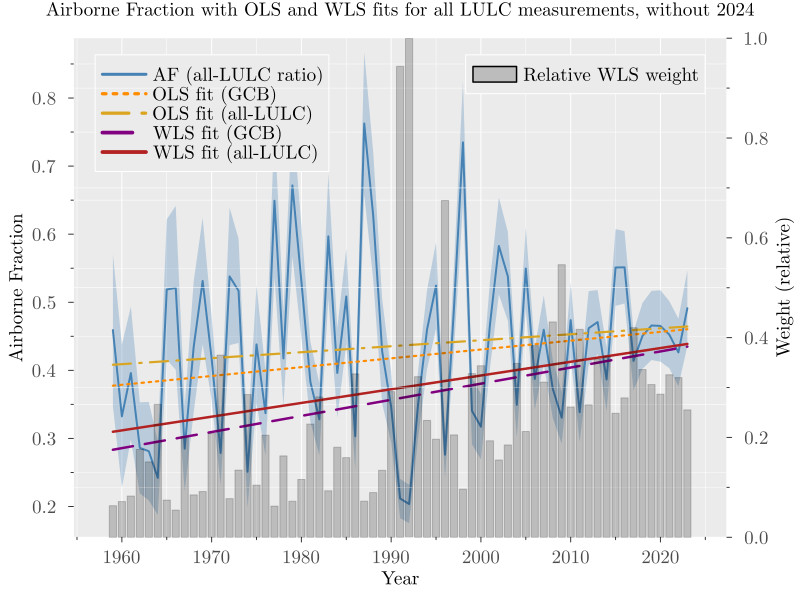

In [1]:
w_rel_2023 = (1 ./ analysis_2023.AF_var) ./ maximum(1 ./ analysis_2023.AF_var)
af_sd_2023 = sqrt.(analysis_2023.AF_var)

p_2023 = plot(
    analysis_2023.Year,
    analysis_2023.AF;
    color = :steelblue,
    linewidth = 2.0,
    label = "AF (all-LULC ratio)",
    ribbon = 1.96 .* af_sd_2023,
    fillalpha = 0.3,
    title = "Airborne Fraction with OLS and WLS fits for all LULC measurements, without 2024",
    xlabel = "Year",
    ylabel = "Airborne Fraction",
    size = (800, 600),
    margin = 3mm,
)
plot!(
    p_2023,
    gcb_2023.Year,
    gcb_2023.AF_ols_trend;
    color = :darkorange,
    linewidth = 2.2,
    linestyle = :dot,
    label = "OLS fit (GCB)",
)
plot!(
    p_2023,
    analysis_2023.Year,
    analysis_2023.AF_ols_trend;
    color = :goldenrod,
    linewidth = 2.2,
    linestyle = :dashdot,
    label = "OLS fit (all-LULC)",
)
plot!(
    p_2023,
    gcb_2023.Year,
    gcb_2023.AF_wls_allw_trend;
    color = :purple,
    linewidth = 2.5,
    linestyle = :dash,
    label = "WLS fit (GCB)",
)
plot!(
    p_2023,
    analysis_2023.Year,
    analysis_2023.AF_wls_trend;
    color = :firebrick,
    linewidth = 2.5,
    linestyle = :solid,
    label = "WLS fit (all-LULC)",
    ylabel = "Airborne Fraction",
    legend = :topleft
)
p2_2023 = twinx()
bar!(
    p2_2023,
    analysis_2023.Year,
    w_rel_2023;
    bar_width = 0.8,
    color = :black,
    alpha = 0.2,
    label = "Relative WLS weight",
    ylabel = "Weight (relative)",
    legend = :topright,
    grid=false
)
p_2023

In [1]:
savefig(p_2023, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_2023_robustness.png"))
savefig(p_2023, joinpath(@__DIR__, "..", "figures", "AF_trends_WLS_2023_robustness.pdf"))

"/Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/figures/AF_trends_WLS_2023_robustness.pdf"

## Results

### Slope

In [1]:
#| results: asis
trend_idx = 2

results_table = DataFrame(
    Metric = [
        "Estimate",
        "Standard error",
        "p-value",
        "R-squared",
    ],
    OLS_GCB_full = [
        model_ols_gcb.β[trend_idx],
        model_ols_gcb.stderr[trend_idx],
        model_ols_gcb.pvalues[trend_idx],
        model_ols_gcb.rsquared,
    ],
    OLS_full = [
        model_ols.β[trend_idx],
        model_ols.stderr[trend_idx],
        model_ols.pvalues[trend_idx],
        model_ols.rsquared,
    ],
    WLS_full = [
        model_wls.β[trend_idx],
        model_wls.stderr[trend_idx],
        model_wls.pvalues[trend_idx],
        model_wls.rsquared,
    ],
    WLS_GCB_AF_allw_full = [
        model_wls_gcbaf_allw.β[trend_idx],
        model_wls_gcbaf_allw.stderr[trend_idx],
        model_wls_gcbaf_allw.pvalues[trend_idx],
        model_wls_gcbaf_allw.rsquared,
    ],
    OLS_up_to_2023 = [
        model_ols_2023.β[trend_idx],
        model_ols_2023.stderr[trend_idx],
        model_ols_2023.pvalues[trend_idx],
        model_ols_2023.rsquared,
    ],
    OLS_GCB_up_to_2023 = [
        model_ols_gcb_2023.β[trend_idx],
        model_ols_gcb_2023.stderr[trend_idx],
        model_ols_gcb_2023.pvalues[trend_idx],
        model_ols_gcb_2023.rsquared,
    ],
    WLS_up_to_2023 = [
        model_wls_2023.β[trend_idx],
        model_wls_2023.stderr[trend_idx],
        model_wls_2023.pvalues[trend_idx],
        model_wls_2023.rsquared,
    ],
    WLS_GCB_AF_allw_up_to_2023 = [
        model_wls_gcbaf_allw_2023.β[trend_idx],
        model_wls_gcbaf_allw_2023.stderr[trend_idx],
        model_wls_gcbaf_allw_2023.pvalues[trend_idx],
        model_wls_gcbaf_allw_2023.rsquared,
    ],
)

fmt_num(x) = string(round(x; digits = 5))

header = "| Trend | OLS (GCB) full | OLS (all) full | WLS (GCB) full |  WLS (all) full | OLS (GCB) up to 2023 | OLS (all) up to 2023 | WLS (GCB) up to 2023 | WLS (all) up to 2023  |"
sep = "|---|---:|---:|---:|---:|---:|---:|---:|---:|"

rows = String[]
for r in eachrow(results_table)
    push!(rows, "| $(r.Metric) | $(fmt_num(r.OLS_GCB_full)) | $(fmt_num(r.OLS_full)) | $(fmt_num(r.WLS_GCB_AF_allw_full))  | $(fmt_num(r.WLS_full)) | $(fmt_num(r.OLS_GCB_up_to_2023)) | $(fmt_num(r.OLS_up_to_2023)) | $(fmt_num(r.WLS_GCB_AF_allw_up_to_2023)) | $(fmt_num(r.WLS_up_to_2023)) |")
end

table_md = join([header, sep, rows...], "\n") * "\n"

println(table_md)

table_out_path = joinpath(@__DIR__, "..", "results", "af_raw_wls_trend.md")
open(table_out_path, "w") do io
    write(io, table_md)
end

println("Saved manuscript-embed table to: $(table_out_path)")

# Export separate slope tables in requested order: OLS (GCB), OLS (all), WLS (GCB), WLS (all)
header_slope = "| Trend | OLS (GCB) | OLS (all) | WLS (GCB) | WLS (all) |"
sep_slope = "|---|---:|---:|---:|---:|"

rows_full = String[]
for r in eachrow(results_table)
    push!(rows_full, "| $(r.Metric) | $(fmt_num(r.OLS_GCB_full)) | $(fmt_num(r.OLS_full)) | $(fmt_num(r.WLS_GCB_AF_allw_full)) | $(fmt_num(r.WLS_full)) |")
end
table_slope_full_md = join([header_slope, sep_slope, rows_full...], "\n") * "\n"

rows_2023 = String[]
for r in eachrow(results_table)
    push!(rows_2023, "| $(r.Metric) | $(fmt_num(r.OLS_GCB_up_to_2023)) | $(fmt_num(r.OLS_up_to_2023)) | $(fmt_num(r.WLS_GCB_AF_allw_up_to_2023)) | $(fmt_num(r.WLS_up_to_2023)) |")
end
table_slope_2023_md = join([header_slope, sep_slope, rows_2023...], "\n") * "\n"

slope_full_out_path = joinpath(@__DIR__, "..", "results", "af_raw_wls_trend_full_sample.md")
open(slope_full_out_path, "w") do io
    write(io, table_slope_full_md)
end

slope_2023_out_path = joinpath(@__DIR__, "..", "results", "af_raw_wls_trend_up_to_2023.md")
open(slope_2023_out_path, "w") do io
    write(io, table_slope_2023_md)
end

println("Saved slope full-sample table to: $(slope_full_out_path)")
println("Saved slope up-to-2023 table to: $(slope_2023_out_path)")

| Trend | OLS (GCB) full | OLS (all) full | WLS (GCB) full |  WLS (all) full | OLS (GCB) up to 2023 | OLS (all) up to 2023 | WLS (GCB) up to 2023 | WLS (all) up to 2023  |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Estimate | 0.00158 | 0.00117 | 0.00265  | 0.0023 | 0.0013 | 0.00088 | 0.00237 | 0.00202 |
| Standard error | 0.00077 | 0.00079 | 2.0e-5  | 2.0e-5 | 0.00078 | 0.0008 | 2.0e-5 | 2.0e-5 |
| p-value | 0.04021 | 0.13891 | 0.0  | 0.0 | 0.09516 | 0.27109 | 0.0 | 0.0 |
| R-squared | 0.06171 | 0.03309 | 0.14899  | 0.11107 | 0.04233 | 0.01886 | 0.12552 | 0.0893 |

Saved manuscript-embed table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_raw_wls_trend.md
Saved slope full-sample table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_raw_wls_trend_full_sample.md
Saved slope up

### Supplementary table: intercept estimates

In [1]:
#| results: asis
intercept_idx = 1

intercept_table = DataFrame(
    Metric = [
        "Estimate",
        "Standard error",
        "p-value",
        "R-squared",
    ],
    OLS_GCB_full = [
        model_ols_gcb.β[intercept_idx],
        model_ols_gcb.stderr[intercept_idx],
        model_ols_gcb.pvalues[intercept_idx],
        model_ols_gcb.rsquared,
    ],
    OLS_full = [
        model_ols.β[intercept_idx],
        model_ols.stderr[intercept_idx],
        model_ols.pvalues[intercept_idx],
        model_ols.rsquared,
    ],
    WLS_full = [
        model_wls.β[intercept_idx],
        model_wls.stderr[intercept_idx],
        model_wls.pvalues[intercept_idx],
        model_wls.rsquared,
    ],
    WLS_GCB_AF_allw_full = [
        model_wls_gcbaf_allw.β[intercept_idx],
        model_wls_gcbaf_allw.stderr[intercept_idx],
        model_wls_gcbaf_allw.pvalues[intercept_idx],
        model_wls_gcbaf_allw.rsquared,
    ],
    OLS_up_to_2023 = [
        model_ols_2023.β[intercept_idx],
        model_ols_2023.stderr[intercept_idx],
        model_ols_2023.pvalues[intercept_idx],
        model_ols_2023.rsquared,
    ],
    OLS_GCB_up_to_2023 = [
        model_ols_gcb_2023.β[intercept_idx],
        model_ols_gcb_2023.stderr[intercept_idx],
        model_ols_gcb_2023.pvalues[intercept_idx],
        model_ols_gcb_2023.rsquared,
    ],
    WLS_up_to_2023 = [
        model_wls_2023.β[intercept_idx],
        model_wls_2023.stderr[intercept_idx],
        model_wls_2023.pvalues[intercept_idx],
        model_wls_2023.rsquared,
    ],
    WLS_GCB_AF_allw_up_to_2023 = [
        model_wls_gcbaf_allw_2023.β[intercept_idx],
        model_wls_gcbaf_allw_2023.stderr[intercept_idx],
        model_wls_gcbaf_allw_2023.pvalues[intercept_idx],
        model_wls_gcbaf_allw_2023.rsquared,
    ],
)

header_int = "| Metric | OLS (GCB) full | OLS (all) full | WLS (GCB ) full | WLS (all) full | OLS (GCB) 2023 | OLS (all) 2023 | WLS (GCB) 2023 | WLS (all) 2023 |"
sep_int = "|---|---:|---:|---:|---:|---:|---:|---:|---:|"

rows_int = String[]
for r in eachrow(intercept_table)
    push!(rows_int, "| $(r.Metric) | $(fmt_num(r.OLS_GCB_full)) | $(fmt_num(r.OLS_full)) | $(fmt_num(r.WLS_GCB_AF_allw_full)) | $(fmt_num(r.WLS_full)) | $(fmt_num(r.OLS_GCB_up_to_2023)) | $(fmt_num(r.OLS_up_to_2023)) | $(fmt_num(r.WLS_GCB_AF_allw_up_to_2023)) | $(fmt_num(r.WLS_up_to_2023)) |")
end

intercept_table_md = join([header_int, sep_int, rows_int...], "\n") * "\n"

println(intercept_table_md)

intercept_out_path = joinpath(@__DIR__, "..", "results", "af_raw_wls_intercept_summary_table.md")
open(intercept_out_path, "w") do io
    write(io, intercept_table_md)
end

println("Saved manuscript-embed table to: $(intercept_out_path)")

| Metric | OLS (GCB) full | OLS (all) full | WLS (GCB ) full | WLS (all) full | OLS (GCB) 2023 | OLS (all) 2023 | WLS (GCB) 2023 | WLS (all) 2023 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Estimate | 0.37141 | 0.40194 | 0.27573 | 0.30194 | 0.3775 | 0.40821 | 0.2834 | 0.30982 |
| Standard error | 0.02904 | 0.02984 | 0.00092 | 0.00095 | 0.02881 | 0.0296 | 0.00091 | 0.00093 |
| p-value | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| R-squared | 0.06171 | 0.03309 | 0.14899 | 0.11107 | 0.04233 | 0.01886 | 0.12552 | 0.0893 |

Saved manuscript-embed table to: /Users/eduardo/Library/CloudStorage/OneDrive-AalborgUniversitet/Research/CLIMATE/AirborneFraction/Airborne-Fraction-WLS-Trend/scripts/../results/af_raw_wls_intercept_summary_table.md